**Random Variabe:**

It is just a variable whose value is determined by a random process.

**Expectation E[X]:**

The average value you'd get if you repeated the experiment infinitely. It is the center of mass of a distribution.

**Variance:**

How spread out the values are around that center. Low variance=your model is consistent. High variance=unpredictable.

**Standard deviation:**

just √Variance. Same unit as your data, so easier to interpret.

When model's prediction have high variance, it means it is sensitive to small changes in training data, that's overfitting.



Expected value (theoretical): 3.5
Expected value (simulated): 3.5055
Variance (theoretical):2.9167
Variance (simulated): 2.9160


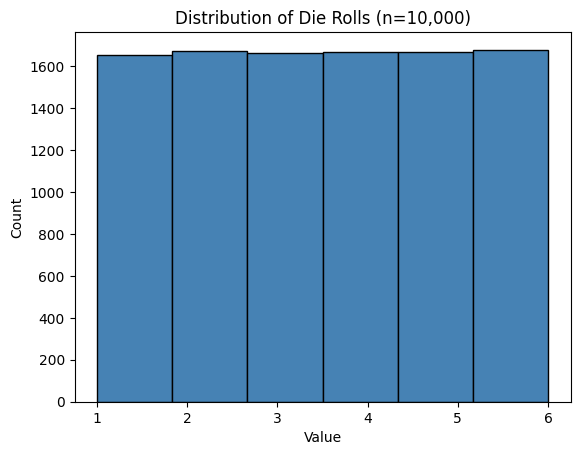

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Simulate rolling a die 10000 times
rolls=np.random.randint(1, 7, size=10000)

print(f"Expected value (theoretical): 3.5")
print(f"Expected value (simulated): {np.mean(rolls):.4f}")
print(f"Variance (theoretical):{35/12:.4f}")
print(f"Variance (simulated): {np.var(rolls):.4f}")

plt.hist(rolls, bins=6, edgecolor='black', color='steelblue')
plt.title("Distribution of Die Rolls (n=10,000)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

Notice how the simulated vales get closer to the theoretical as n grows. This is the law of Large Numbers, and it's why we need large datasets in ML.

It has learned the pattern.

**Probability Distribution:**

**Gaussian(Normal)** Bell Curve

What it models: Continous, symmetric data

ML use: Assumptions in linear regression, initialising neural network weights.

Gausian models continous data that's symmetrci around a mean, like initializing weights in neural network so they start balanced not skewed.

**Bernouli** Coin Flip

What it models: Single yes/no event

ML use: Binary classification output

Bernouli is a signle yes/no event, like the output of the binary classification, is this cat or not?

**Binomial** Multiple coin flips

What it models: Count of successes in n trials

ML use: Evaluating classifiers

Binomial counts successes in n trials, like evaluating how many times a classifier was correct out of 100 tests.

**Uniform** Flat Land-Everything's equal

What it models: Equal probability everywhere

ML use: random initialization, dropout

Uniform means equal probability everywhere, used for random initialization so that no one is favoured, like dropout randomly selecting neurons.



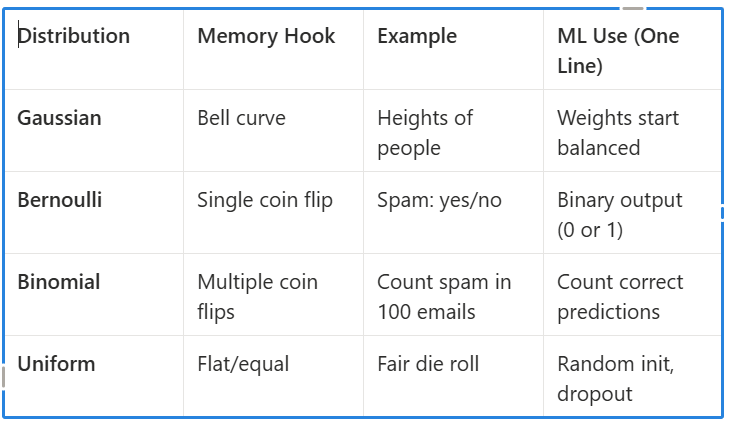

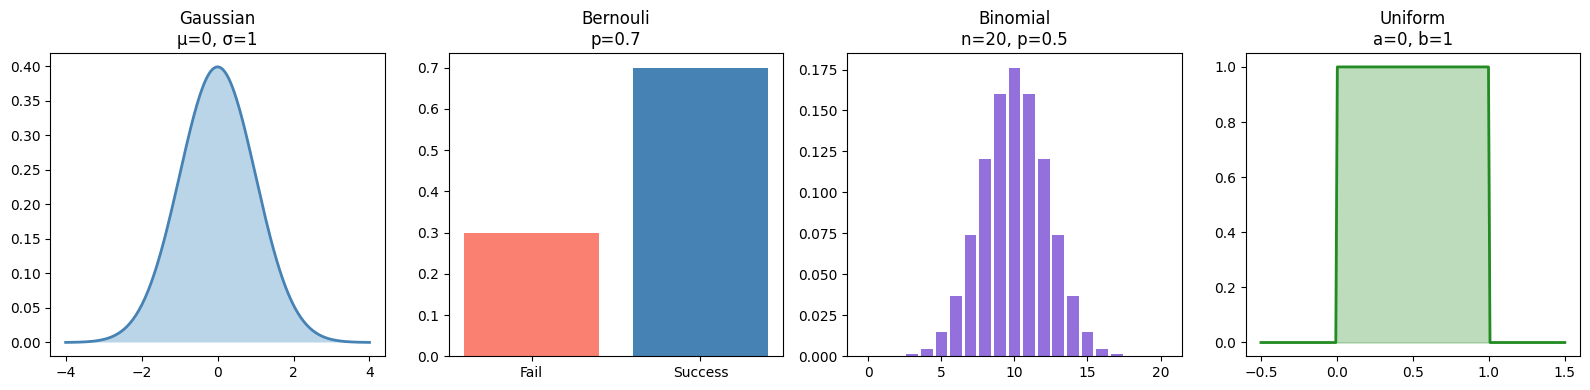

In [ ]:
from scipy import stats
fig, axes=plt.subplots(1,4, figsize=(16,4))

#Gausian
x=np.linspace(-4, 4, 200)
axes[0].plot(x, stats.norm.pdf(x,0,1), color='steelblue', linewidth=2)
axes[0].set_title("Gaussian\nμ=0, σ=1")
axes[0].fill_between(x, stats.norm.pdf(x,0,1), alpha=0.3)

#Bernouli
axes[1].bar([0,1], [0.3, 0.7], color=['salmon', 'steelblue'])
axes[1].set_title("Bernouli\np=0.7")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Fail', 'Success'])

#Binomial
x_binom=np.arange(0,21)
axes[2].bar(x_binom, stats.binom.pmf(x_binom, 20, 0.5), color='mediumpurple')
axes[2].set_title("Binomial\nn=20, p=0.5")

#Uniform
x_unif=np.linspace(-0.5, 1.5, 200)
axes[3].plot(x_unif, stats.uniform.pdf(x_unif, 0, 1), color='forestgreen', linewidth=2)
axes[3].fill_between(x_unif, stats.uniform.pdf(x_unif, 0, 1), alpha=0.3, color='forestgreen')
axes[3].set_title("Uniform\na=0, b=1")

plt.tight_layout()
plt.show()

**Bayes' Theorem**

P(A∣B)=P(B∣A)⋅P(A)/P(B)

P(hypothesis|data) = p(data|hypothesis).P(hypothesis)/p(data)

* p(hypothesis|data)=posterior, what you believe after seeing the data
* p(data|hypothesis)=Likelihood, how probable is this data if the hypothesis is true(clues)
* p(hypothesis)=prior, what you believed before seeing the data(hunch)
* p(data), evidence, just a normalizing constant

e.g: detective work:
* prior: your hunch before investigating.
* Likelihood: The clues that you find(how well they match your hunch)
* posterior: your updated belief after seeing the clues.

**Real Example:**
A medical test is 99% accurate. A disease affects 1% of the population(base rate). you test positive. what is the actual probability you have the disease?

**Out of 10,000 people:**

- **100 have the disease** (1% of 10,000)
- **9,900 are healthy**

**After testing:**

- **99 sick people test positive** (99% of 100)
- **99 healthy people ALSO test positive** (1% of 9,900 — false alarms!)

**Total positives:** 99 + 99 = **198 people**

**Actually sick:** Only **99 out of 198** = **50%**

Bayes theorem updates probabilities based on new evidence. It combines your prior belief with the likelihood of the data to give a posteior probability. the classic example is a medical test: even a 99% accurate test can give only 50% certainty if the disease id rare, because false positives outnumber true positives. this explains why class imbalance breaks naive classifiers, because a 99% majority class makes everything look accurate even when the model is useless.





In [ ]:
p_disease=0.01 #prior: 1% population has disease
p_positive_given_disease=0.99 #Sensitivity
p_posiive_given_no_disease=0.01 #False positive rate

#P(positive)=total prabability
p_positive=(p_positive_given_disease * p_disease + p_posiive_given_no_disease * (1-p_disease)) #1-p_disease=population wit no disease

# Bayes P(disease|positive)
p_disease_given_positive=(p_positive_given_disease * p_disease)/p_positive
print(f"P(disease) before test: {p_disease:.0%}")
print(f"P(positive test result): {p_positive:.4f}")
print(f"P(disease | positive test): {p_disease_given_positive:.2%}")
print()
print("Surprised? This is WHY class imbalance destroys naive classifiers.")
print("And why in ML we always ask: what's the base rate?")

P(disease) before test: 1%
P(positive test result): 0.0198
P(disease | positive test): 50.00%

Surprised? This is WHY class imbalance destroys naive classifiers.
And why in ML we always ask: what's the base rate?


50% despite 99% accurate test, is called the base rate fallacy. It directly explains why a model trained on 99% majority class that predicts everything as majority class looks "99% accurate" but is completely useless.

### The Base Rate Fallacy

**Definition:** Ignoring base rates and focusing only on specific evidence.

**Classic mistake:**

"The test is 99% accurate, so if I test positive, I'm 99% likely to be sick!"

**Wrong!** You forgot the base rate (disease is rare), so false positives dominate.

**MLE vs MAP**

**Maximum Likelihood Estimation(MLE)**

find the parameters θ that makes your observed data most probable.

θ^MLE​=argθmax​P(data∣θ) pick the theta(paarmeter) that maximizes the probability of seeing your data.

In practice we maximize the log-likelihood

θ^MLE​=argθmax​i∑​logP(xi​∣θ)

example: tossed a coin 10 times: you observed 7 head, 3 tails.

MLE asks: What probability p makes this outcome most likely?

Answer: p=0.7 (70%)

Another example: Fitting a Bell Curve

Scenario: You measure the heights of 100 people. they look like a bell curve.

Question: What is teh avg height? what is teh spread?

MLE says:

Best guess for avg: the mean of your data.

Best guess for spread: teh std of your data.

This is MLE for Gaussian distribution.



True μ: 5.00
True σ: 2.00
MLE μ: 5.01
MLE σ: 1.9605
Unbiased σ: 1.9625
Notice: MLE slightly underestimates σ — it's a biased estimator!
This is why pandas uses ddof=1 by default in .std()


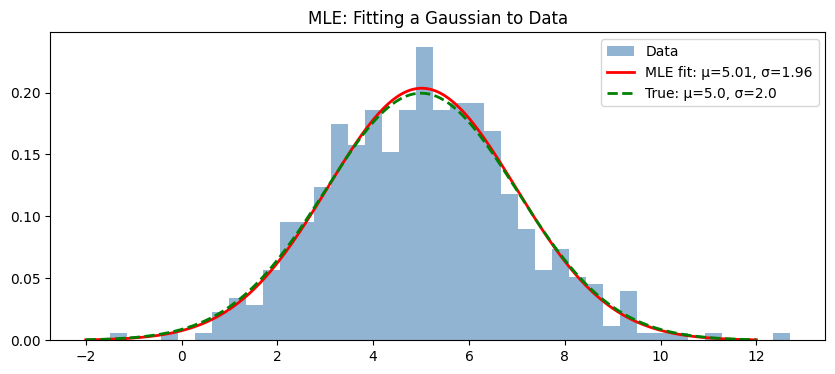

In [ ]:
#Generate data from an unknown Gaussian
np.random.seed(42)
true_mu, true_sigma=5.0,2.0
data=np.random.normal(true_mu, true_sigma, size=500)

#MLE estimates (analytical solution for Gaussian)
mu_mle=np.mean(data)
sigma_mle=np.std(data) #MLE for sigma (divides by n, not n-1)
sigma_unbiased=np.std(data, ddof=1) #unbiased (divides by n-1)

print(f"True μ: {true_mu:.2f}")
print(f"True σ: {true_sigma:.2f}")
print(f"MLE μ: {mu_mle:.2f}")
print(f"MLE σ: {sigma_mle:.4f}")
print(f"Unbiased σ: {sigma_unbiased:.4f}")

print("Notice: MLE slightly underestimates σ — it's a biased estimator!")
print("This is why pandas uses ddof=1 by default in .std()")

# Visualise
x = np.linspace(-2, 12, 300)
plt.figure(figsize=(10, 4))
plt.hist(data, bins=40, density=True, alpha=0.6, color='steelblue', label='Data')
plt.plot(x, stats.norm.pdf(x, mu_mle, sigma_mle),
         'r-', linewidth=2, label=f'MLE fit: μ={mu_mle:.2f}, σ={sigma_mle:.2f}')
plt.plot(x, stats.norm.pdf(x, true_mu, true_sigma),
         'g--', linewidth=2, label=f'True: μ={true_mu}, σ={true_sigma}')
plt.legend(); plt.title("MLE: Fitting a Gaussian to Data")
plt.show()

when you train a classifier with cross-entropy loss, you are doing MLE.

Your model outputs probabilities: p(class|input)

MLE says: "Pick weight that makes the true classes most probable."

Minimizing cross-entropy=Maximizing Likelihood.

**Maximum A Posteriori**

MAP=MLE+a prior belief about the parameters.

θ^MAP​=argθmax​P(data∣θ)⋅P(θ) Picks the thetha that makes the data likely AND matched your prior belief.

You flip a coin 3 times and get 3 head.
MLE says; the coin has 100% heads! (3 out of 3)

But your brain says: Wait, that is only 3 flips. Most coins are fair. It's probably close to 50%, just got lucky.

MAP balances data and prior, more data=less influence from prior.

MLE: Only looks at data
MAP: Data + prior belief

MAP with Gaussian prior on weights=L2 regularization (Ridge)

MAP with Laplace prior on weights=L1 regularization (Lasso)

When you add λ||w||² to your loss function (L2 reg), you are penalizing large weights, you are doing Bayesian inference with a prior that believes weights should be small.

In [ ]:
# Show how MAP pulls estimates toward prior
# Imagine we only have 5 data points (small data)
np.random.seed(42)
small_data = np.random.normal(5.0, 2.0, size=5)

# MLE (no prior)
mu_mle_small = np.mean(small_data)

# MAP with prior: mu ~ N(0, 1) — we believe mu is near 0
# MAP estimate: weighted combination of prior and data
prior_mu, prior_strength = 0.0, 1.0
n = len(small_data)
sigma_known = 2.0

# MAP formula for Gaussian with known variance
map_weight = n / (n + sigma_known**2 / prior_strength**2)
mu_map = map_weight * mu_mle_small + (1 - map_weight) * prior_mu

print(f"Data: {small_data.round(2)}")
print(f"MLE estimate: {mu_mle_small:.4f}  (only trusts data)")
print(f"MAP estimate: {mu_map:.4f}  (pulled toward prior of 0)")
print()
print("With only 5 points, MAP is more cautious.")
print("As n → ∞, MAP → MLE (data overwhelms the prior).")

Data: [5.99 4.72 6.3  8.05 4.53]
MLE estimate: 5.9180  (only trusts data)
MAP estimate: 3.2878  (pulled toward prior of 0)

With only 5 points, MAP is more cautious.
As n → ∞, MAP → MLE (data overwhelms the prior).


**Imagine a number line:**

- **Prior belief:** "μ should be near 0"
- **Data says:** "μ is near 5" (based on 5 samples)
- **MLE:** Ignores prior, picks 5
- **MAP:** Compromises, picks something like 3 (weighted average of prior and data)

**As you get more data, MAP moves closer to MLE (data wins!)**

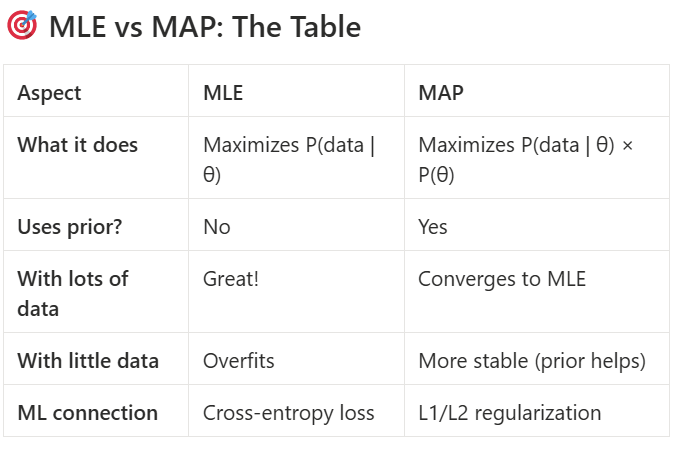

MLE finds parameters that make the observed data most likely. MAP does the same but also incorporates a prior belief about the parameters. For example, if i flipa coin 3 times and get 3 heads, MLE says the coin is 100% heads, but MAP says it's probably closer to 50% because most coins are fair. In ML, cross-entropy loss is MLE, and L2 reg is MAP with a GAUSSIAN prior, that is why regularization prevents overfitting: It encodes a belief that weights shoudl be small.

**BIAS-VARIANCE Tradeoff**

The expected error of any model can be decomposed as:

Error=Bias^2 + variance + irreducible noise

Bias: how wrong your model is on average. High bias=underfitting. Your models assumptions are too simple.

Variance: How much your model changes when trained on different data. High variance=overfitting. Your model memorised the training set.

Irreducible noise: No model can eliminate this. It's randomness in the real world.

A high bias model (Like Linear regression on non-Linear data) will be consistently wrong in the same way.

A high variance model (like a degree-15 polynomial) will be wildly different each time, fitting noise.

A model complex enought to understand patterns but simple enough not to memorize  noise.

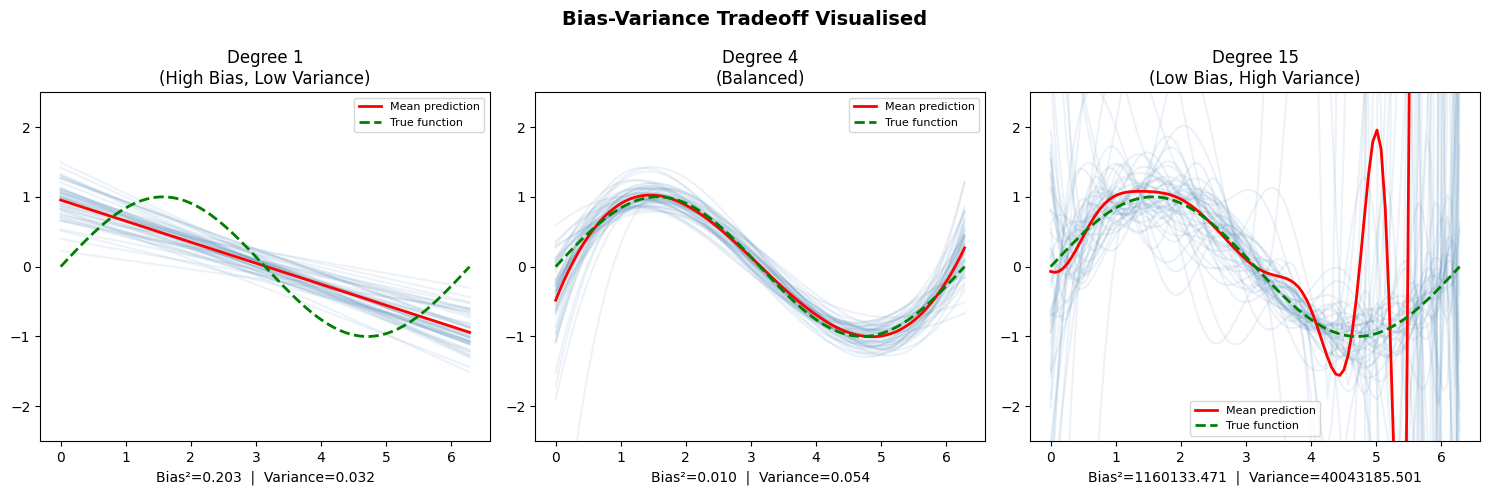

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

np.random.seed(42)

#True Function: sin(x)
def true_function(x):
  return np.sin(x)  #true function we are trying to learn

X_test=np.linspace(0, 2*np.pi, 100) #100 evenly spaced points from 0 to 2pi, this is wheer we will test our model
y_test_true=true_function(X_test) #the actual sin values at those points (the ground truth)

n_experiments=50 #train 50 diff models for each polynomial degree, to see how much model varies, each time we get diff training data
predictions={1: [], 4: [], 15: []}

for _ in range(n_experiments):
  #Sample 20 noisy training points
  X_train=np.random.uniform(0, 2*np.pi, 20) #20 random x-values
  y_train=true_function(X_train)+np.random.normal(0,0.3,20) #sin values +random noise
  #each experiment gets diff training data, we can see how stable/unstable the model is

  for degree in [1, 4, 15]: #1: staright line, 4: moderately curve, 15 extremely wiggly
    model =Pipeline([ # combines polynomial feature + LR into one step
        ('poly', PolynomialFeatures(degree)), #ransform x into [x^2, x^3...]
        ('lr', LinearRegression())
    ])
    model.fit(X_train.reshape(-1,1), y_train) #train model on the 20 noisy points
    pred=model.predict(X_test.reshape(-1,1)) #make predictions on all 100 test points
    predictions[degree].append(pred) # save this experiment's predictions
    #after this loop completes:
    #predictions[1] contains 50 diff predictio curves (one per experiemnt) for degree 1
    #predictions[4] contains 50 diff predictions curves for degree 4
    #predictions[15] contains 50 diff predictions curves for degree 15

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) #create 3 side by side plots (one for each degree)
titles = {1: "Degree 1\n(High Bias, Low Variance)",
          4: "Degree 4\n(Balanced)",
          15: "Degree 15\n(Low Bias, High Variance)"}

for ax, degree in zip(axes, [1, 4, 15]):
    preds = np.array(predictions[degree]) #all 50 predictions curves for this degree(50*100)
    mean_pred = preds.mean(axis=0) #avg prediction across all 50 experiments

    # Plot individual experiment predictions (faint)
    for p in preds:
        ax.plot(X_test, p, alpha=0.1, color='steelblue')

    ax.plot(X_test, mean_pred, 'r-', linewidth=2, label='Mean prediction')
    ax.plot(X_test, y_test_true, 'g--', linewidth=2, label='True function')
    ax.set_title(titles[degree])
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=8)

    bias_sq = np.mean((mean_pred - y_test_true)**2) # how far the avg prediction (red line) is from truth(green line): Avg of (mean pred-true value)^2
    variance = np.mean(preds.var(axis=0)) #How spread out the 50 predictions are, computes variance at each of the 100 test points, then avg across all points
    ax.set_xlabel(f"Bias²={bias_sq:.3f}  |  Variance={variance:.3f}")

plt.suptitle("Bias-Variance Tradeoff Visualised", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- **Degree 1 (Linear):** Consistently wrong (high bias) but all predictions cluster together (low variance). The faint blue lines all look similar — stable but incorrect.
- **Degree 4:** Balanced! Gets close to the true function and doesn't swing too wildly between experiments.
- **Degree 15:** Hits close to the truth sometimes but swings wildly (high variance). Look at those faint lines — they're all over the place! Different training sets produce completely different curves.

**Every regularization technique is fighting the bias-variance tradeoff:**

- **L2 regularization (Ridge):** Shrinks coefficients → Increases bias, decreases variance
- **L1 regularization (Lasso):** Sets some coefficients to zero → Increases bias, decreases variance
- **Dropout:** Randomly kills neurons → Prevents co-adaptation (high variance)
- **Early stopping:** Stop before fully fitting training data → Prevents overfitting (high variance)
- **Ensemble methods (Random Forest, Bagging):** Average many high-variance models → Reduces variance!

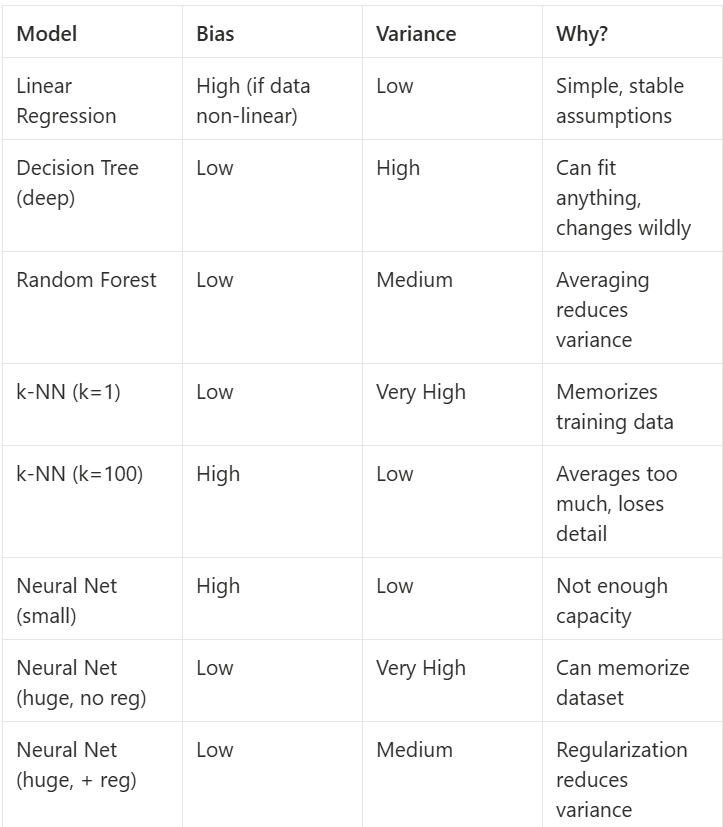

The biad-variance tradeoff states that a model's expected error decomposes into three parts: bias squared, variance, and ireedicible noise. Bias measures how wrong the model is on average, high bias means underfitting, like fitting a line to a curve. Variance mearures how much the model changes with different training data, high variance means overfitting, like memorizing noise. Simple models have high bias and low variance. Complex models have low bias and high variance. the goal is to find the sweet spot that minimizes total error. For e.g, in polynomial regression, degree 1 undefits, degree 15 overfits, and degree 4 might just be right. Regularization techniques like L2 deliberately increase bias to reduce variance, which is why they prevent overfitting.